In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

### Loading data

In [2]:
# Selecting the brain region
select_region = "Isocortex-1"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Count the number of cells in each class
class_counts = adata.obs["class"].value_counts()

# Identify classes with few cells
n_cells_threshold = 100

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
# classes_to_remove.append("08 CNU-MGE GABA")
adata = adata[~adata.obs["class"].isin(classes_to_remove)].copy()

In [5]:
# Loading the DEG dataframe
group_by = "class"
select_region = "Isocortex-1"
deg_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results = pd.read_csv(deg_path)
deg_results.head(3)

,01 IT-ET Glut,02 NP-CT-L6b Glut,05 OB-IMN GABA,06 CTX-CGE GABA,07 CTX-MGE GABA,08 CNU-MGE GABA,30 Astro-Epen,31 OPC-Oligo,33 Vascular,34 Immune
0,C1ql3,Hs3st4,H3f3b,Adarb2,Kcnc2,Sox2ot,Plpp3,Olig1,Sparc,Laptm5
1,Cck,Cdh18,Zbtb20,Dlx6os1,Rab3b,Alk,Slc1a3,Qk,Utrn,Inpp5d
2,Tafa1,Foxp2,Msi2,Gad1,Slc32a1,Nkain3,Slc1a2,Gjc3,Zbtb20,Cst3


In [6]:
adata.var.set_index("gene_symbol", inplace=True)
adata.var_names = adata.var_names.astype(str)
adata.var_names_make_unique()

### Load test dataset

In [7]:
# Loading AnnData object
select_region = "Isocortex-2"
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata_test = sc.read_h5ad(expr_path)
adata_test

AnnData object with n_obs × n_vars = 227537 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [8]:
# Count the number of cells in each class
class_counts = adata_test.obs["class"].value_counts()

# Identify classes with few cells
n_cells_threshold = 100

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
classes_to_remove.remove("08 CNU-MGE GABA")
adata_test = adata_test[~adata_test.obs["class"].isin(classes_to_remove)].copy()

In [9]:
adata_test.var.set_index("gene_symbol", inplace=True)
adata_test.var_names = adata_test.var_names.astype(str)
adata_test.var_names_make_unique()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy import sparse

# Parameters
n_top_genes = 5  # Number of top DEGs per class

# 1. Collect top genes from each class in deg_results
top_genes = []
for cls in deg_results.columns:
    top_genes += deg_results[cls].dropna().head(n_top_genes).tolist()
top_genes = list(dict.fromkeys(top_genes))  # Remove duplicates, preserve order

# 2. Prepare feature matrices and labels
X_train = adata[:, top_genes].X
X_test = adata_test[:, top_genes].X

if sparse.issparse(X_train):
    X_train = X_train.toarray()
if sparse.issparse(X_test):
    X_test = X_test.toarray()

y_train = adata.obs[group_by].values
y_test = adata_test.obs[group_by].values

# 3. Compute class weights from training data
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# 4. Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict, n_jobs=8)
clf.fit(X_train, y_train)

# 5. Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

    01 IT-ET Glut       1.00      1.00      1.00     75121
02 NP-CT-L6b Glut       0.99      1.00      1.00      7557
   05 OB-IMN GABA       1.00      0.67      0.80       118
  06 CTX-CGE GABA       0.99      1.00      0.99      9952
  07 CTX-MGE GABA       1.00      0.99      0.99      5480
  08 CNU-MGE GABA       1.00      0.96      0.98        49
    30 Astro-Epen       1.00      1.00      1.00     44691
     31 OPC-Oligo       1.00      1.00      1.00     38473
      33 Vascular       1.00      1.00      1.00     23257
        34 Immune       1.00      1.00      1.00     22728

         accuracy                           1.00    227426
        macro avg       1.00      0.96      0.98    227426
     weighted avg       1.00      1.00      1.00    227426



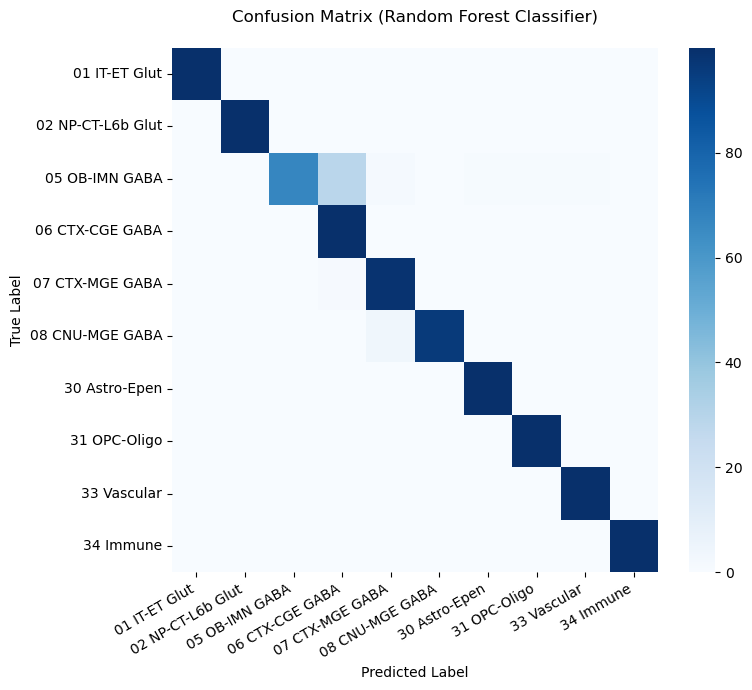

In [15]:
# Compute confusion matrix (absolute counts or normalize with normalize='true')
cm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true') * 100

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=False, fmt='.1f', cmap='Blues', xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Random Forest Classifier)\n")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"figures/confusion_matrix_{select_region}.svg")
plt.show()

### Random forest on internal data

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy import sparse

# Parameters
n_top_genes = 5  # Number of top DEGs per class

# 1. Collect top genes from each class
top_genes = []
for cls in deg_results.columns:
    top_genes += deg_results[cls].dropna().head(n_top_genes).tolist()
top_genes = list(dict.fromkeys(top_genes))  # Remove duplicates, preserve order

# 2. Prepare feature matrix X and labels y
X = adata[:, top_genes].X
if sparse.issparse(X):
    X = X.toarray()
y = adata.obs[group_by].values

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 4. Compute class weights to handle imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# 5. Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict, n_jobs=-1)
clf.fit(X_train, y_train)

# 6. Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

                   precision    recall  f1-score   support

    01 IT-ET Glut       1.00      1.00      1.00     24365
02 NP-CT-L6b Glut       1.00      1.00      1.00     11502
   05 OB-IMN GABA       1.00      0.74      0.85        43
  06 CTX-CGE GABA       0.99      1.00      0.99      2538
  07 CTX-MGE GABA       1.00      0.99      0.99      2680
  08 CNU-MGE GABA       1.00      0.95      0.98        86
    30 Astro-Epen       1.00      1.00      1.00      1274
     31 OPC-Oligo       1.00      1.00      1.00      1293
      33 Vascular       1.00      1.00      1.00       963
        34 Immune       1.00      1.00      1.00       721

         accuracy                           1.00     45465
        macro avg       1.00      0.97      0.98     45465
     weighted avg       1.00      1.00      1.00     45465

Confusion matrix:
 [[24346    18     0     1     0     0     0     0     0     0]
 [   14 11488     0     0     0     0     0     0     0     0]
 [    1     0    32     5 

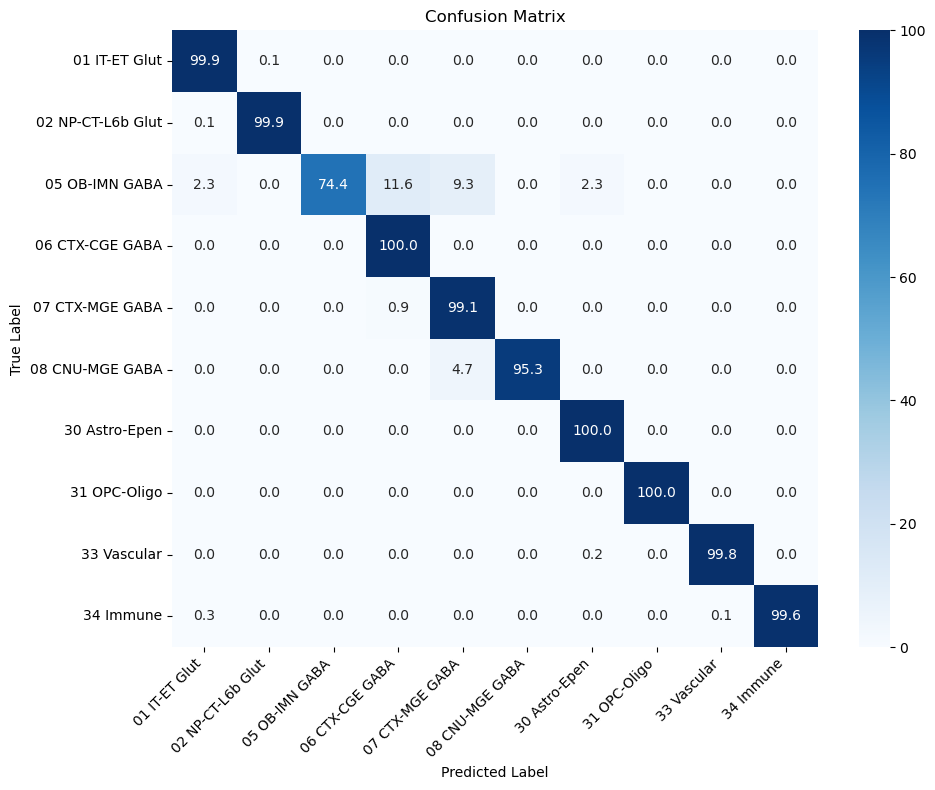

In [ ]:
# Compute confusion matrix (absolute counts or normalize with normalize='true')
cm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true') * 100

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"confusion_matrix_{select_region}.svg")
plt.show()

### Classifier: leakage-free nested CV

In [17]:
import scanpy as sc
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy import sparse

# adata          : your AnnData object (already QC’d & normalised)
# group_by       : column in adata.obs with the ABCA cell-class labels
# random_state   : just pick one number and reuse it everywhere
random_state = 42

In [ ]:
def compute_degs(adata_subset, group_by, n_top=5):
    """
    Re-run Wilcoxon DE test on an AnnData slice and
    return a list of n_top DEGs per class (no duplicates).
    """
    sc.tl.rank_genes_groups(
        adata_subset,
        groupby       = group_by,
        method        = "wilcoxon",
        pts=True,  # keep consistency with your notebook
        n_genes=None  # analyse all genes, we will slice later
    )

    rgg = adata_subset.uns["rank_genes_groups"]["names"]  # structured array
    genes = []
    for cls in rgg.dtype.names:          # class order preserved
        genes.extend(list(rgg[cls][:n_top]))
    # remove duplicates while preserving order
    return list(dict.fromkeys(genes))

In [ ]:
def fit_and_score(adata, train_idx, test_idx, genes):
    """
    Train a class-weighted RandomForest on <genes> and
    return macro-F1 plus per-class report / confusion matrix.
    """
    # --- build matrices ---
    X_train = adata[train_idx, genes].X
    X_test  = adata[test_idx,  genes].X

    # if sparse, materialise (n_cells × n_genes is small)
    if sparse.issparse(X_train):
        X_train = X_train.toarray()
    if sparse.issparse(X_test):
        X_test = X_test.toarray()

    y_train = adata.obs[group_by].values[train_idx]
    y_test  = adata.obs[group_by].values[test_idx]

    # class weights from TRAIN only
    classes = np.unique(y_train)
    w = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    clf = RandomForestClassifier(
        n_estimators = 200,
        class_weight = dict(zip(classes, w)),
        n_jobs       = -1,
        random_state = random_state
    ).fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    report   = classification_report(y_test, y_pred, output_dict=True)
    cm       = confusion_matrix(y_test, y_pred)
    return macro_f1, report, cm

In [20]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state+1)

n_gene_grid = [3, 5, 10, 20]   # same spirit as your original “top-5” choice

outer_scores   = []
outer_reports  = []
outer_cms      = []

labels = adata.obs[group_by].values

for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(adata.X, labels), 1):
    # ---------------- inner loop: choose best n_top_genes ----------------
    best_f1, best_n = -np.inf, None
    for n_top in n_gene_grid:
        inner_scores = []
        for inner_train, inner_val in inner_cv.split(train_idx, labels[train_idx]):
            genes = compute_degs(adata[train_idx][inner_train], group_by, n_top)
            f1, _, _ = fit_and_score(adata, train_idx[inner_train], train_idx[inner_val], genes)
            inner_scores.append(f1)
        mean_f1 = np.mean(inner_scores)
        if mean_f1 > best_f1:
            best_f1, best_n = mean_f1, n_top

    # ---------------- outer evaluation with leakage-free gene list -------
    final_genes = compute_degs(adata[train_idx], group_by, best_n)
    f1, report, cm = fit_and_score(adata, train_idx, test_idx, final_genes)

    outer_scores.append(f1)
    outer_reports.append(report)
    outer_cms.append(cm)

    print(f"Fold {outer_fold}: n_top={best_n:2d} | macro-F1={f1:.3f}")

# -------------- overall performance --------------
print(f"\nOverall macro-F1 = {np.mean(outer_scores):.3f} ± {np.std(outer_scores):.3f}")

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-pack

Fold 1: n_top=20 | macro-F1=0.998


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-pack

Fold 2: n_top=20 | macro-F1=0.995


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-pack

Fold 3: n_top=20 | macro-F1=0.989


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-pack

Fold 4: n_top=20 | macro-F1=0.994


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-pack

Fold 5: n_top=20 | macro-F1=0.994

Overall macro-F1  =  0.994 ± 0.003
